## **1. EfficientNet-B3 - Transfer learning + Fine tuning**

In this notebook we report the first experiment performed during our challenge. The training set is built of **224x224-sized patches**, extracted from the original WSI images exploiting the information provided by binary masks. The model, trained both with transfer learning and fine tuning, consists of an **EficientNet-B3** FEN plus an MLP classifier. WSI-level predictions are generated by averaging patch-level softmax probabilities per WSI.

## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/challenge2AN2DL"
%cd $current_dir

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/.shortcut-targets-by-id/1sSQJKU_eQUTptnQou58Hgxaj8RPPeM6b/challenge2AN2DL


## ⚙️ **Libraries Import**

In [ ]:
# Set seed for reproducibility
SEED = 42

experiment_name = "effcient_net_baseline"
sub_name = "effcient_net_baseline"

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
from glob import glob

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

# Tensorboard configuration
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
from concurrent.futures import ThreadPoolExecutor
import pickle

!pip install lion-pytorch
from lion_pytorch import Lion

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.9.0+cu126
Device: cuda


## ⏳ **Data Loading**

In [ ]:
# train_data_dictionary = { "img_XXXX.png" : (224,224,3) }, where:
#   - XXXX is the zero-padded patch index
#   - (224,224,3) is a 3D matrix describing the patch
#   - pixel values are already between 0 and 1
dict_path = "dataset/patches_224/train_data_dictionary.pkl"

with open(dict_path, "rb") as f:
    X_train_val_dict = pickle.load(f)

print("Train data dictionary loaded! Number of images: ", len(X_train_val_dict))
print("Examples of image names: ", list(X_train_val_dict.keys())[:5])

# "cleaned_patched_train_labels.csv" is a csv file with the following columns:
#   - "index" -> patch index
#   - "label" -> label of the WSI from which the patch was extracted
#   - "original_idx" -> index of the WSI from which the patch was extracted
y_train_val_df = pd.read_csv('dataset/patches_224/cleaned_patched_train_labels.csv')
y_train_val_df['index'] = y_train_val_df['index'].astype(int)
y_train_val_df['filename'] = y_train_val_df['index'].apply(lambda x: f"img_{x:04d}.png")

unique_labels = sorted(y_train_val_df['label'].unique().tolist())
print("Train labels loaded! Unique labels: ", unique_labels)
print("Number of original images: ", y_train_val_df['original_idx'].nunique())

Train data dictionary loaded! Number of images:  2763
Examples of image names:  ['img_0001.png', 'img_0002.png', 'img_0003.png', 'img_0004.png', 'img_0005.png']
Train labels loaded! Unique labels:  ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']
Number of original images:  581


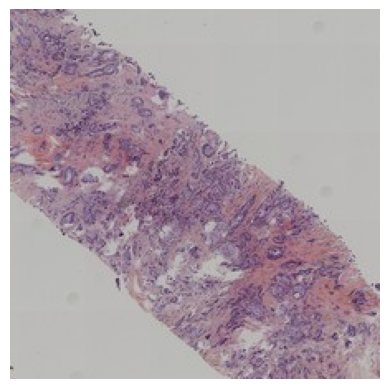

In [ ]:
# Example of training patch
plt.imshow((X_train_val_dict["img_1342.png"]*255).astype(np.uint8))
plt.axis('off')
plt.show()

In [ ]:
# Label distribution in the training-validation set
label_counts = y_train_val_df['label'].value_counts().sort_index()

print("Label distribution in the dataset:\n")
for label, count in label_counts.items():
    print(f"Label {label}: {count/len(y_train_val_df)} samples")

print("\nTotal number of patches:", len(y_train_val_df))

Label distribution in the dataset:

Label HER2(+): 0.26601520086862107 samples
Label Luminal A: 0.2703583061889251 samples
Label Luminal B: 0.35685848715164675 samples
Label Triple negative: 0.1067680057908071 samples

Total number of patches: 2763


##  📄 **Data Preprocessing**

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# This function takes as input the training-validation dictionary and the training-validation dataframe
# It performs stratified splitting between training and validation set, avoiding data leakage (patches belonging to the same WSI will be in the same set)
# It returns the splitted dataframes and dictionaries for training and validation

def stratified_group_split(df, X_dict, val_size=0.2, random_state=42):

    # Input check
    assert 'label' in df.columns
    assert 'original_idx' in df.columns
    assert 'filename' in df.columns

    y = df['label'].values
    groups = df['original_idx'].values

    # K-fold splitting
    n_splits = int(round(1.0 / val_size))
    if n_splits < 2:
        raise ValueError("val_size too big, should be < 0.5.")

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # We take one fold for validation, the other ones are used for training
    X_placeholder = np.zeros(len(df))
    train_idx, val_idx = next(sgkf.split(X_placeholder, y, groups))

    # Training and validation dataframes
    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_val   = df.iloc[val_idx].reset_index(drop=True)

    train_filenames = df_train['filename'].values
    val_filenames   = df_val['filename'].values

    # Training and validation dictionaries
    X_train_dict = {fn: X_dict[fn] for fn in train_filenames}
    X_val_dict   = {fn: X_dict[fn] for fn in val_filenames}

    # Label distribution in the training and validation sets
    print("Dimensions:")
    print("  train:", len(X_train_dict), "patch")
    print("  val  :", len(X_val_dict), "patch")
    print()

    print("TRAIN label distribution:")
    print(df_train['label'].value_counts().sort_index()/len(X_train_dict))
    print("\nVAL label distribution:")
    print(df_val['label'].value_counts().sort_index()/len(X_val_dict))
    print("\nTOTAL label distribution:")
    print(df['label'].value_counts().sort_index()/len(X_dict))

    # Data leakage check
    n_leakages = len(set(df_train['original_idx']).intersection(set(df_val['original_idx'])))
    print("\nNumber of data leakage occurrences:", n_leakages)

    return X_train_dict, X_val_dict, df_train, df_val

In [ ]:
# 80-20 training-validation splitting
X_train_dict, X_val_dict, y_train_df, y_val_df = stratified_group_split(
    y_train_val_df,
    X_train_val_dict,
    val_size=0.2,
    random_state=SEED
)

Dimensions:
  train: 2246 patch
  val  : 517 patch

TRAIN label distribution:
label
HER2(+)            0.272039
Luminal A          0.259127
Luminal B          0.363313
Triple negative    0.105521
Name: count, dtype: float64

VAL label distribution:
label
HER2(+)            0.239845
Luminal A          0.319149
Luminal B          0.328820
Triple negative    0.112186
Name: count, dtype: float64

TOTAL label distribution:
label
HER2(+)            0.266015
Luminal A          0.270358
Luminal B          0.356858
Triple negative    0.106768
Name: count, dtype: float64

Number of data leakage occurrences: 0


In [ ]:
# This funcion takes as input the training (or validation) dictionary and dataframe
# It returns a numpy matrix containing the pixel values of all the patches and a numpy array of patch labels

def build_xy_from_dict_and_df(X_dict, y_df):

    filenames = y_df['filename'].values

    # We contruct an ordered patch list
    X_list = []
    for fn in filenames:
        img = X_dict[fn]              # (H, W, 3)
        # HWC -> CHW tranformation for PyTorch compatibility
        img_chw = np.transpose(img, (2, 0, 1))   # (3, H, W)
        X_list.append(img_chw)

    # 4D matrix of pixels (N_patches, 3, 224, 224)
    X = np.stack(X_list, axis=0).astype(np.float32)

    # Label array
    y = y_df['label'].values

    return X, y

In [ ]:
# Building of pixel matrices and label arrays

X_train, y_train = build_xy_from_dict_and_df(X_train_dict, y_train_df)
X_val, y_val = build_xy_from_dict_and_df(X_val_dict, y_val_df)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (2246, 3, 224, 224)
y_train shape: (2246,)
X_val shape: (517, 3, 224, 224)
y_val shape: (517,)


In [ ]:
# Map the categorical labels to numerical values

label_mapping = {
    "HER2(+)": 0,
    "Luminal A": 1,
    "Luminal B": 2,
    "Triple negative": 3
}

y_train = np.array([label_mapping[x] for x in y_train])
y_val = np.array([label_mapping[x] for x in y_val])


print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

y_train shape: (2246,)
y_val shape: (517,)


In [ ]:
# Define the input shape and number of classes
input_shape = (3, 224, 224)
num_classes = 4

print("Input Shape:", input_shape)
print("Number of Classes:", num_classes)

Input Shape: (3, 224, 224)
Number of Classes: 4


In [ ]:
# Define the batch size
BATCH_SIZE = 32

In [ ]:
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class TissueDataset(torch.utils.data.Dataset):
    """Custom PyTorch Dataset with optional augmentation and normalization."""

    def __init__(self, data, labels, augmentation=None, normalize_imagenet=False):
        """
        Args:
            data: numpy array of images (N, C, H, W) in range [0, 1]
            labels: numpy array of labels
            augmentation: transforms for data augmentation
            normalize_imagenet: whether to apply ImageNet normalization
        """
        self.data = torch.from_numpy(data)
        self.labels = torch.from_numpy(labels).long()
        self.augmentation = augmentation
        self.normalize_imagenet = normalize_imagenet

        # ImageNet normalization transform
        if normalize_imagenet:
            self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        else:
            self.normalize = None

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].clone()  # Clone to avoid modifying original
        label = self.labels[idx]

        # Apply augmentation if provided (on images in [0, 1] range)
        if self.augmentation:
            image = self.augmentation(image)

        # Apply ImageNet normalization if requested
        if self.normalize:
            image = self.normalize(image)

        return image, label

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """Create a PyTorch DataLoader with optimized settings."""
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

##  🧮 **Network Parameters**

In [ ]:
# Training parameters
LEARNING_RATE = 1e-3
EPOCHS = 200
PATIENCE = 20

# Regularization
DROPOUT_RATE = 0.3
L2_LAMBDA = 5e-5

# Setup weighted cross-entropy loss
class_distributions = {
    cls: np.sum(y_train == cls) / len(y_train)
    for cls in [0, 1, 2, 3]
}
class_weights = list(class_distributions.values())
class_weights = [1/x for x in class_weights]
print(class_weights)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("Patience:", PATIENCE)

[np.float64(3.6759410801963996), np.float64(3.8591065292096216), np.float64(2.752450980392157), np.float64(9.476793248945148)]
Epochs: 200
Batch Size: 32
Learning Rate: 0.001
Dropout Rate: 0.3
Patience: 20


## 🧠 **Model Training**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## 🛠️ **Transfer Learning**

In [ ]:
class EfficientNetB3TransferLearning(nn.Module):
    """EfficientNet-BX with ImageNet pretrained weights."""

    def __init__(self, num_classes, dropout_rate=0.3, freeze_backbone=True):
        super().__init__()

        # Load weights pretrained on ImageNet
        self.backbone = torchvision.models.efficientnet_b3(
            weights=torchvision.models.EfficientNet_B3_Weights.DEFAULT
        )

        # Freeze the backbone layers (features)
        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False

        # Replace classifier (Always trainable)
        in_features = self.backbone.classifier[-1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, in_features // 2),
            nn.BatchNorm1d(in_features // 2),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(in_features // 2, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

In [ ]:
# Create transfer learning model
tl_model = EfficientNetB3TransferLearning(num_classes, DROPOUT_RATE, freeze_backbone=True).to(device)

# Display model summary
summary(tl_model, input_size=input_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 40, 112, 112]           1,080
       BatchNorm2d-2         [-1, 40, 112, 112]              80
              SiLU-3         [-1, 40, 112, 112]               0
            Conv2d-4         [-1, 40, 112, 112]             360
       BatchNorm2d-5         [-1, 40, 112, 112]              80
              SiLU-6         [-1, 40, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 40, 1, 1]               0
            Conv2d-8             [-1, 10, 1, 1]             410
              SiLU-9             [-1, 10, 1, 1]               0
           Conv2d-10             [-1, 40, 1, 1]             440
          Sigmoid-11             [-1, 40, 1, 1]               0
SqueezeExcitation-12         [-1, 40, 112, 112]               0
           Conv2d-13         [-1, 24, 112, 112]             960
      BatchNorm2d-14         [-1, 24, 1

In [ ]:
# Define augmentation for training patches
train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=50, translate=(0.2, 0.2)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2))
])

# Create datasets with ImageNet normalization
train_tl_ds = TissueDataset(X_train, y_train, augmentation=train_augmentation, normalize_imagenet=True)
val_tl_ds = TissueDataset(X_val, y_val, augmentation=None, normalize_imagenet=True)

# Create data loaders for training and validation sets
train_tl_loader = make_loader(train_tl_ds, BATCH_SIZE, shuffle=True, drop_last=False)
val_tl_loader = make_loader(val_tl_ds, BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Training setup
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)

# Lion optimizer
optimizer = Lion(tl_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Scaler
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
%%time
# Train with transfer learning
tl_model, training_history = fit(
    model=tl_model,
    train_loader=train_tl_loader,
    val_loader=val_tl_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE
)

# Update best model if current performance is superior
if max(training_history['val_f1']) > best_performance:
    best_model = tl_model
    best_performance = max(training_history['val_f1'])


Training 200 epochs...
Epoch   1/200 | Train: Loss=1.5339, F1 Score=0.2985 | Val: Loss=1.6139, F1 Score=0.2594
Epoch   2/200 | Train: Loss=1.4672, F1 Score=0.3352 | Val: Loss=1.5564, F1 Score=0.3316
Epoch   3/200 | Train: Loss=1.4537, F1 Score=0.3271 | Val: Loss=1.5462, F1 Score=0.3333
Epoch   4/200 | Train: Loss=1.4223, F1 Score=0.3566 | Val: Loss=1.6420, F1 Score=0.3241
Epoch   5/200 | Train: Loss=1.4086, F1 Score=0.3403 | Val: Loss=1.6138, F1 Score=0.2847
Epoch   6/200 | Train: Loss=1.4020, F1 Score=0.3754 | Val: Loss=1.6566, F1 Score=0.2977
Epoch   7/200 | Train: Loss=1.3955, F1 Score=0.3587 | Val: Loss=1.5219, F1 Score=0.3121
Epoch   8/200 | Train: Loss=1.3506, F1 Score=0.3712 | Val: Loss=1.6527, F1 Score=0.2770
Epoch   9/200 | Train: Loss=1.3552, F1 Score=0.3730 | Val: Loss=1.7242, F1 Score=0.2774
Epoch  10/200 | Train: Loss=1.3784, F1 Score=0.3644 | Val: Loss=1.5588, F1 Score=0.3128
Epoch  11/200 | Train: Loss=1.3457, F1 Score=0.3788 | Val: Loss=1.5762, F1 Score=0.3026
Epoch  12

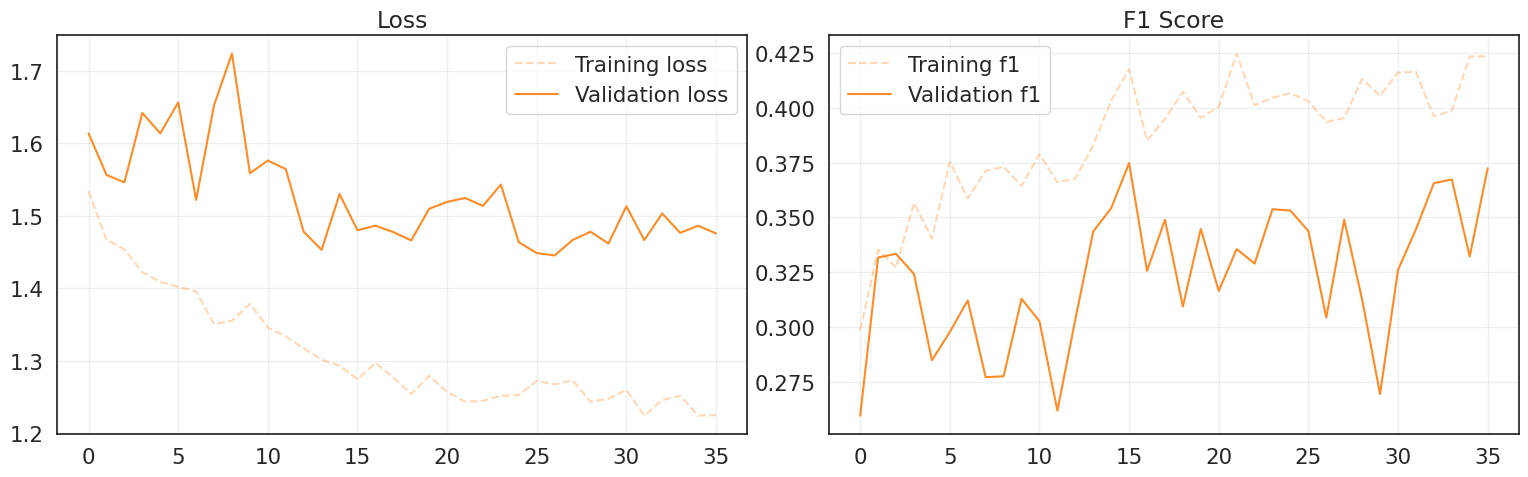

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.3675
Precision over the validation set: 0.3801
Recall over the validation set: 0.3675
F1 score over the validation set: 0.3642


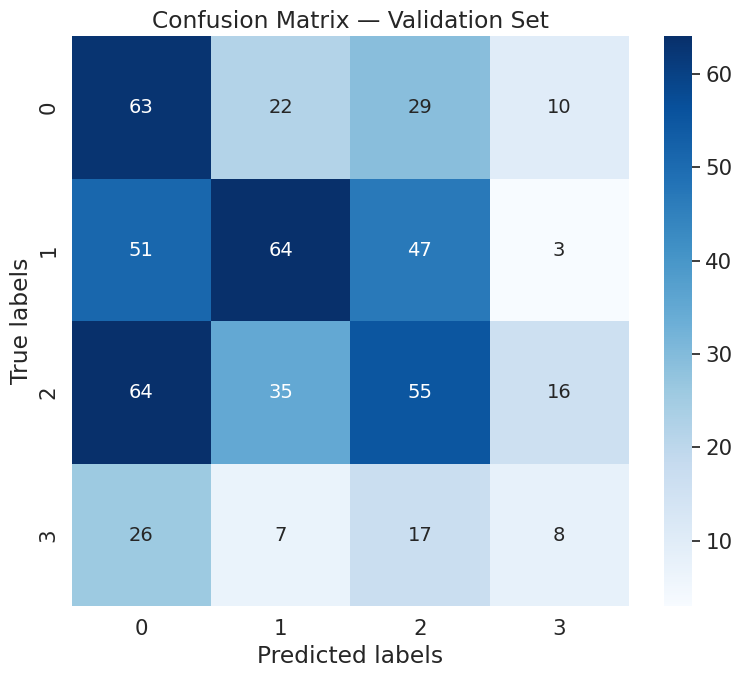

In [ ]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_tl_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## 🛠️ **Fine-Tuning**

In [ ]:
# Load the transfer learning weights
ft_model = tl_model

# Unfreeze the last N layers of the backbone
N_LAYERS_TO_UNFREEZE = 2

# Freeze everything first
for param in ft_model.parameters():
    param.requires_grad = False

# The classifier is always trainable
for param in ft_model.backbone.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last blocks of the feature extractor
for block in ft_model.backbone.features[-N_LAYERS_TO_UNFREEZE:]:
    for param in block.parameters():
        param.requires_grad = True

# Check trainable parameters
trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")


Trainable parameters: 5,062,142 / 11,881,260


In [ ]:
# Training setup
experiment_name = experiment_name+"_FT"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)

# Optimizer (we use a smaller learning rate for fine tuning)
optimizer = Lion(ft_model.parameters(), lr=LEARNING_RATE*0.1, weight_decay=L2_LAMBDA)

# Scaler
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
%%time
# Fine-tune the model
ft_model, ft_history = fit(
    model=ft_model,
    train_loader=train_tl_loader,
    val_loader=val_tl_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE
)

# Update best model if current performance is superior
if max(ft_history['val_f1']) > best_performance:
    best_model = ft_model
    best_performance = max(ft_history['val_f1'])

Training 200 epochs...
Epoch   1/200 | Train: Loss=1.2505, F1 Score=0.3925 | Val: Loss=1.4639, F1 Score=0.3790
Epoch   2/200 | Train: Loss=1.2288, F1 Score=0.4330 | Val: Loss=1.5213, F1 Score=0.3493
Epoch   3/200 | Train: Loss=1.1878, F1 Score=0.4438 | Val: Loss=1.6068, F1 Score=0.3720
Epoch   4/200 | Train: Loss=1.1428, F1 Score=0.4752 | Val: Loss=1.6215, F1 Score=0.3684
Epoch   5/200 | Train: Loss=1.0988, F1 Score=0.4848 | Val: Loss=1.6467, F1 Score=0.3997
Epoch   6/200 | Train: Loss=1.0735, F1 Score=0.4821 | Val: Loss=1.7274, F1 Score=0.3605
Epoch   7/200 | Train: Loss=1.0429, F1 Score=0.5160 | Val: Loss=1.6781, F1 Score=0.3719
Epoch   8/200 | Train: Loss=1.0456, F1 Score=0.5116 | Val: Loss=1.7167, F1 Score=0.3665
Epoch   9/200 | Train: Loss=0.9620, F1 Score=0.5547 | Val: Loss=1.8462, F1 Score=0.3777
Epoch  10/200 | Train: Loss=0.9566, F1 Score=0.5602 | Val: Loss=1.8999, F1 Score=0.3770
Epoch  11/200 | Train: Loss=0.9139, F1 Score=0.5933 | Val: Loss=1.9892, F1 Score=0.3912
Epoch  12

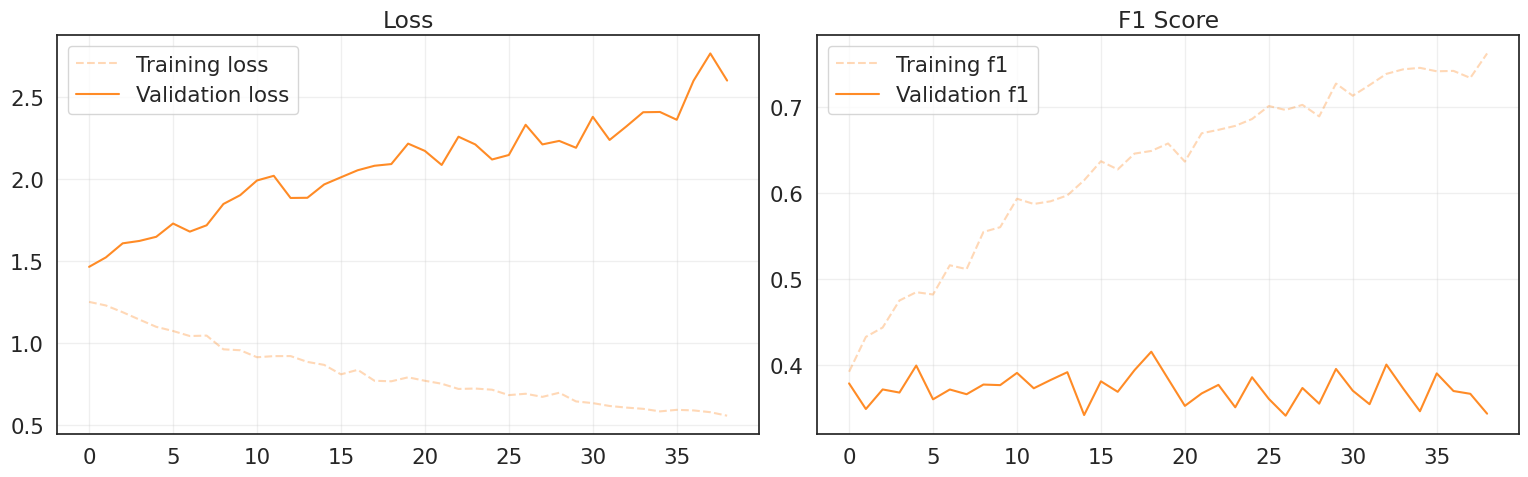

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(ft_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(ft_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(ft_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(ft_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## 🧠 **Inference**


In [ ]:
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class TissueTestDataset(torch.utils.data.Dataset):
    """Custom PyTorch Dataset with optional augmentation and normalization."""

    def __init__(self, data, augmentation=None, normalize_imagenet=False):

        """
        Args:
            data: numpy array of images (N, C, H, W) in range [0, 1]
            augmentation: transforms for data augmentation
            normalize_imagenet: whether to apply ImageNet normalization
        """

        self.data = torch.from_numpy(data)
        self.augmentation = augmentation
        self.normalize_imagenet = normalize_imagenet


        # ImageNet normalization transform
        if normalize_imagenet:
            self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        else:
            self.normalize = None

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].clone()  # Clone to avoid modifying original

        # Apply augmentation if provided (on images in [0, 1] range)
        if self.augmentation:
            image = self.augmentation(image)

        # Apply ImageNet normalization if requested
        if self.normalize:
            image = self.normalize(image)

        return image

In [ ]:
# test_data is a directory containing png test patches
test_dir  = 'dataset/patches_224/test_data'

# "cleaned_patched_test_indices.csv" is a csv file with the following columns:
#   - "index" -> patch index
#   - "original_idx" -> index of the WSI from which the patch was extracted
test_map_csv = 'dataset/patches_224/cleaned_patched_test_indices.csv'

# Load the csv file
df = pd.read_csv(test_map_csv)
df['index'] = df['index'].astype(int)
df['filename'] = df['index'].apply(lambda x: f"img_{x:04d}.png")
filenames = df['filename'].tolist()

# Function for test patch loading
def load_one_image(filename):
    img_path = os.path.join(test_dir, filename)
    img = Image.open(img_path).convert('RGB')
    img_array = (np.array(img, dtype=np.float32) / 255.0)
    img_array = np.transpose(img_array, (2, 0, 1))
    return img_array

test_array = []

i = 1
# Multiple workers to speed up the loading process
with ThreadPoolExecutor(max_workers=16) as executor:
    for arr in executor.map(load_one_image, filenames):
        test_array.append(arr)
        if i % 50 == 0:
          print(f"{i}/{len(filenames)}")
        i += 1

# (N_patches, 3, 224, 224) numpy matrix containing the pixel values (between 0 and 1) of all the test patches
X_test = np.stack(test_array, axis=0)

print(X_test.shape)


50/2285
100/2285
150/2285
200/2285
250/2285
300/2285
350/2285
400/2285
450/2285
500/2285
550/2285
600/2285
650/2285
700/2285
750/2285
800/2285
850/2285
900/2285
950/2285
1000/2285
1050/2285
1100/2285
1150/2285
1200/2285
1250/2285
1300/2285
1350/2285
1400/2285
1450/2285
1500/2285
1550/2285
1600/2285
1650/2285
1700/2285
1750/2285
1800/2285
1850/2285
1900/2285
1950/2285
2000/2285
2050/2285
2100/2285
2150/2285
2200/2285
2250/2285
(2285, 3, 224, 224)


In [ ]:
# Create data loader for test set
test_ds = TissueTestDataset(X_test, augmentation=None, normalize_imagenet=True)
test_loader = make_loader(test_ds, BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
import torch.nn.functional as F

def inference(model, test_loader, device):
    """
    Perform inference on the test dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        test_loader (DataLoader): PyTorch DataLoader containing test data batches
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        list: A list of numpy arrays, where each array contains predictions for a batch.
    """

    model.eval()  # Set model to evaluation mode

    all_probs = []

    # Disable gradient computation for inference
    with torch.no_grad():
        for inputs in test_loader:
            # Move data to device
            inputs = inputs.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)

            # Accumulate probabilities
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    return all_probs

In [ ]:
# Perform inference on the test patches
probabilities = inference(best_model, test_loader, device)

# Generate a numpy matrix containing the softmax probabilities for each patch
probabilities = np.concatenate(probabilities, axis=0)

In [ ]:
test_mapping = pd.read_csv(test_map_csv)

# Attach the wsi index to each corresponding row of patch probabilities
orig_idx = test_mapping["original_idx"].values

# Create the corresponding dataframe
probs_df = pd.DataFrame(probabilities)
probs_df["original_idx"] = orig_idx

# Average probabilities per wsi
avg_probs_df = probs_df.groupby("original_idx").mean()

# Convert back to numpy
avg_probs = avg_probs_df.to_numpy()           # shape: (num_original_samples, num_classes)

# Final predictions: argmax over classes
predictions = avg_probs.argmax(axis=1).tolist()        # shape: (num_original_samples,)

In [ ]:
# Inverse label mapping for submission csv file
mapping_label = {
    0: "HER2(+)",
    1: "Luminal A",
    2: "Luminal B",
    3: "Triple negative"
}

# Submission csv generation
pred_df = pd.DataFrame({
    "sample_index": [f"img_{i:04d}.png" for i in range(len(predictions))],
    "label": [mapping_label[int(x)] for x in predictions]
})

pred_df.to_csv("submissions/"+sub_name+".csv", index=False)